# OLS Modeling - dataset3 (diff_only + dummies)

- 데이터: `../data/Finance_Final/dataset3_diff_only_with_dummies.csv`
- 타깃: `oil_diff_target` (= 다음날 OilPrice 의 1차 차분)
- 일단 OLS 적합만.


In [7]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

DATA_PATH = Path("../data/Finance_Final/dataset3_diff_only_with_dummies.csv")
TARGET = "oil_diff_target"

df = pd.read_csv(DATA_PATH, parse_dates=["date"]).set_index("date").sort_index()
print("shape:", df.shape)
print("기간:", df.index.min().date(), "~", df.index.max().date())
df.head()


shape: (4799, 27)
기간: 2007-02-01 ~ 2026-03-16


,oil_diff_target,RealInterestRate,CPI,DollarIndex,VIX,IndustryProduction,CPE,OilInventories,OPECProduction,OilProduction,TreasuryYield,FedFundsRate,gfc_2008_shock,gfc_2008_regime,opec_2014_shock,opec_2014_regime,covid_2020_shock,covid_2020_regime,war_2022_shock,war_2022_regime,gfc_2008_window,opec_2014_window,covid_2020_window,war_2022_window,cond_vix_spike,cond_inventory_draw,cond_opec_cut
date,,,,,,,,,,,,,,,,,,,,,,,,,,,
2007-02-01,1.66,0.139075,0.789,-0.2539,-0.11,0.9407,-2.8,2684.0,106.499,-17.0,0.01,0.01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2007-02-02,-0.32,0.139075,0.789,0.2642,-0.23,0.9407,-2.8,-518.0,106.499,59.0,-0.01,0.01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2007-02-05,0.22,0.139075,0.789,-0.1043,0.47,0.9407,-2.8,-518.0,106.499,59.0,-0.02,0.01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2007-02-06,-1.16,0.139075,0.789,-0.1343,0.10,0.9407,-2.8,-518.0,106.499,59.0,-0.04,0.01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2007-02-07,2.01,0.139075,0.789,-0.0118,-0.33,0.9407,-2.8,-518.0,106.499,59.0,-0.03,0.01,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
# 결측 확인 및 제거
print("결측 합계 (상위 10개):")
print(df.isna().sum().sort_values(ascending=False).head(10))

df_model = df.dropna(subset=[TARGET]).copy()
df_model = df_model.dropna()
print(f"\n모델링 대상 표본 수: {len(df_model)}")


결측 합계 (상위 10개):
oil_diff_target        1
opec_2014_shock        0
cond_inventory_draw    0
cond_vix_spike         0
war_2022_window        0
covid_2020_window      0
opec_2014_window       0
gfc_2008_window        0
war_2022_regime        0
war_2022_shock         0
dtype: int64

모델링 대상 표본 수: 4798


In [9]:
# 설명변수 / 타깃 분리
feature_cols = [c for c in df_model.columns if c != TARGET]
print(f"설명변수 개수: {len(feature_cols)}")
print(feature_cols)

X = sm.add_constant(df_model[feature_cols])
y = df_model[TARGET]


설명변수 개수: 26
['RealInterestRate', 'CPI', 'DollarIndex', 'VIX', 'IndustryProduction', 'CPE', 'OilInventories', 'OPECProduction', 'OilProduction', 'TreasuryYield', 'FedFundsRate', 'gfc_2008_shock', 'gfc_2008_regime', 'opec_2014_shock', 'opec_2014_regime', 'covid_2020_shock', 'covid_2020_regime', 'war_2022_shock', 'war_2022_regime', 'gfc_2008_window', 'opec_2014_window', 'covid_2020_window', 'war_2022_window', 'cond_vix_spike', 'cond_inventory_draw', 'cond_opec_cut']


In [10]:
# OLS 적합
ols = sm.OLS(y, X).fit()
print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:        oil_diff_target   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.786
Date:                Sat, 09 May 2026   Prob (F-statistic):            0.00837
Time:                        11:30:37   Log-Likelihood:                -10140.
No. Observations:                4798   AIC:                         2.033e+04
Df Residuals:                    4771   BIC:                         2.051e+04
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.0096    

In [11]:
# 핵심 지표 요약
dw = durbin_watson(ols.resid)
print(f"R²            : {ols.rsquared:.4f}")
print(f"Adj R²        : {ols.rsquared_adj:.4f}")
print(f"F-statistic   : {ols.fvalue:.4f}  (p = {ols.f_pvalue:.4g})")
print(f"AIC / BIC     : {ols.aic:.2f} / {ols.bic:.2f}")
print(f"Durbin-Watson : {dw:.4f}")
print(f"표본 수 / 변수 수: {int(ols.nobs)} / {len(feature_cols)}")


R²            : 0.0096
Adj R²        : 0.0042
F-statistic   : 1.7862  (p = 0.008369)
AIC / BIC     : 20334.35 / 20509.20
Durbin-Watson : 2.2662
표본 수 / 변수 수: 4798 / 26


In [12]:
# 유의(p<0.05) 변수만 정렬해서 보기
coef_df = pd.DataFrame({
    "coef": ols.params,
    "std_err": ols.bse,
    "t": ols.tvalues,
    "p_value": ols.pvalues,
}).drop(index="const", errors="ignore")

sig = coef_df[coef_df["p_value"] < 0.05].sort_values("p_value")
print(f"5% 유의수준 변수: {len(sig)}개")
sig


5% 유의수준 변수: 3개


,coef,std_err,t,p_value
war_2022_window,1.503829,0.612526,2.455128,0.014119
DollarIndex,0.192263,0.080841,2.378281,0.017433
CPI,0.102987,0.050592,2.035625,0.041843


## 2. VIF 점검
다중공선성 진단. 일반적으로 VIF > 10 이면 심각, 5 이상이면 주의.

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# add_constant 포함된 X 그대로 사용 (const 자체는 VIF 계산에서 보통 제외해서 봄)
vif_df = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
})
vif_df = vif_df[vif_df["variable"] != "const"].sort_values("VIF", ascending=False).reset_index(drop=True)

print("VIF > 10 (심각):", (vif_df["VIF"] > 10).sum(), "개")
print("VIF > 5  (주의):", (vif_df["VIF"] > 5).sum(), "개")
vif_df


VIF > 10 (심각): 0 개
VIF > 5  (주의): 0 개


,variable,VIF
0,CPE,4.459875
1,IndustryProduction,3.981896
2,OPECProduction,3.650675
3,covid_2020_shock,3.327887
4,OilInventories,2.226731
5,FedFundsRate,2.225153
6,cond_inventory_draw,2.157463
7,gfc_2008_shock,2.156475
8,covid_2020_window,2.145189
9,cond_opec_cut,2.050144


## 3. 잔차 진단
### 3-1. 자기상관: ACF / PACF + Ljung-Box + Durbin-Watson

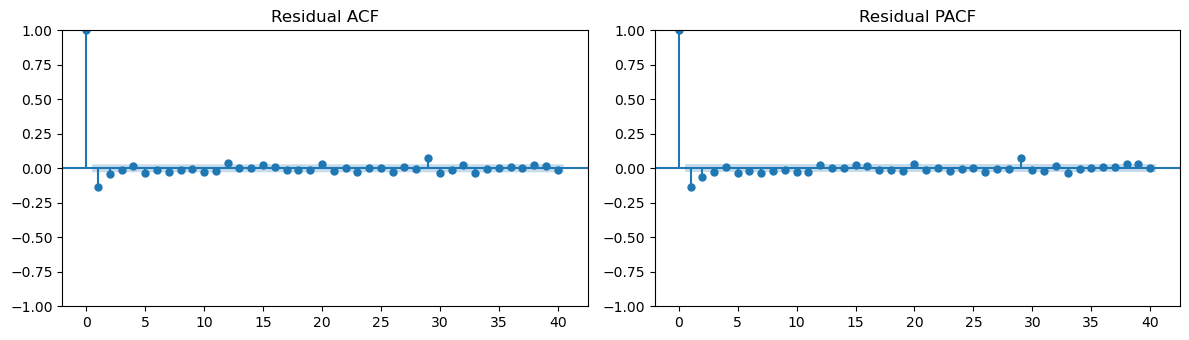

In [14]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

resid = ols.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_acf(resid, lags=40, ax=axes[0])
axes[0].set_title("Residual ACF")
plot_pacf(resid, lags=40, ax=axes[1], method="ywm")
axes[1].set_title("Residual PACF")
plt.tight_layout()
plt.show()


In [15]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Ljung-Box (lag 10, 20)
lb = acorr_ljungbox(resid, lags=[5, 10, 20], return_df=True)
print("===== Ljung-Box test (H0: 자기상관 없음) =====")
print(lb)

dw = durbin_watson(resid)
print(f"\nDurbin-Watson = {dw:.4f}  (≈2: 무자기상관, <1.5: 양의 자기상관 의심, >2.5: 음의 자기상관 의심)")

# 판정
lb_p_min = lb["lb_pvalue"].min()
print("\n[판정]")
if lb_p_min < 0.05:
    print(f" - Ljung-Box 최소 p={lb_p_min:.4g} < 0.05  →  자기상관 존재 (Bad)")
else:
    print(f" - Ljung-Box 최소 p={lb_p_min:.4g} ≥ 0.05  →  자기상관 없음 (Good)")


===== Ljung-Box test (H0: 자기상관 없음) =====
       lb_stat     lb_pvalue
5   103.777708  8.441604e-21
10  110.000458  5.334604e-19
20  129.194794  5.518568e-18

Durbin-Watson = 2.2662  (≈2: 무자기상관, <1.5: 양의 자기상관 의심, >2.5: 음의 자기상관 의심)

[판정]
 - Ljung-Box 최소 p=8.442e-21 < 0.05  →  자기상관 존재 (Bad)


### 3-2. 이분산성: Breusch-Pagan 검정

In [16]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_stat, bp_p, bp_f, bp_fp = het_breuschpagan(resid, X)
print("===== Breusch-Pagan test (H0: 등분산) =====")
print(f"LM statistic   = {bp_stat:.4f}")
print(f"LM p-value     = {bp_p:.4g}")
print(f"F  statistic   = {bp_f:.4f}")
print(f"F  p-value     = {bp_fp:.4g}")

print("\n[판정]")
if bp_p < 0.05:
    print(f" - p={bp_p:.4g} < 0.05  →  이분산성 존재 (Bad)")
else:
    print(f" - p={bp_p:.4g} ≥ 0.05  →  등분산 (Good)")


===== Breusch-Pagan test (H0: 등분산) =====
LM statistic   = 537.1517
LM p-value     = 7.034e-97
F  statistic   = 23.1333
F  p-value     = 2.914e-103

[판정]
 - p=7.034e-97 < 0.05  →  이분산성 존재 (Bad)


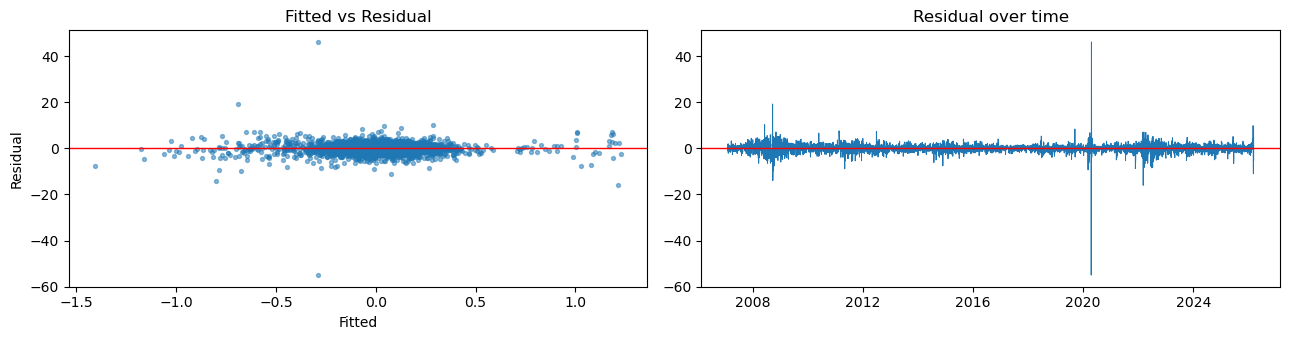

In [ ]:
# 잔차 시각화 (적합값 vs 잔차, 잔차 시계열) - 이분산/구조적 패턴 확인용
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

axes[0].scatter(ols.fittedvalues, resid, s=8, alpha=0.5)
axes[0].axhline(0, color="red", lw=1)
axes[0].set_xlabel("Fitted")
axes[0].set_ylabel("Residual")
axes[0].set_title("Fitted vs Residual")

axes[1].plot(resid.index, resid, lw=0.7)
axes[1].axhline(0, color="red", lw=1)
axes[1].set_title("Residual over time")

plt.tight_layout()
plt.show()